# Smartphone Addiction - MBML Project Plan of Attack

This notebook outlines our project for the Model-Based Machine Learning course. Below is our tentative step-by-step plan:

### Phase 1: Data Understanding & Preprocessing
*   **EDA**: Understand distributions, correlations, and target variables (Completed in this notebook).
*   **Imputation**: The `addiction_level` column has missing values. We will treat these as missing latent states and use a probabilistic model (e.g., Gaussian Mixture Model or Bayesian imputation) to infer them rather than discarding rows.

### Phase 2: Baseline Modeling
*   **Bayesian Logistic Regression**: Establish a strong baseline for predicting `addicted_label` using Pyro.
*   **Prior Tuning**: Experiment with different priors (e.g., weak vs. strong, Laplace for sparsity) to see how they affect the learned weights and uncertainty.

### Phase 3:  Probabilistic Modeling 
*   **Generative Graphical Model**: Build a Directed Acyclic Graph (DAG) representing the causal relationships between age, stress, screen time variations, and addiction.
*   **Latent Variable Models**: Introduce a latent variable (e.g., `digital_dependency`) that governs both screen time behavior and perceived stress.
*   **Hierarchical Modeling**: Model subgroups (by gender, age group, or student/worker status) with hierarchical priors to capture group-level baseline effects vs. individual variances.

### Phase 4: Inference & Evaluation
*   **Inference Techniques**: Compare Variational Inference (SVI) with Markov Chain Monte Carlo (MCMC/NUTS) if computationally feasible.
*   **Posterior Predictive Checks**: Simulate data from our trained models and compare against the actual dataset to see if our generative assumptions hold up.
*   **Model Criticism**: Evaluate using Information Criteria (like WAIC or LOO).

### Phase 5: Synthesis
*   Compile findings, explaining the causal insights vs. just predictive performance.
*   Visualize uncertainty in our predictions for edge-case users.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# In notebooks, you can use Path.cwd() to get the current working directory
# or use relative paths directly.
parent_dir = Path.cwd().parent
data_dir = parent_dir / "data" / "data.csv"

# If the data folder is in the same directory as the notebook's parent:
# data_dir = Path("../data/data.csv")

df = pd.read_csv(data_dir)

# Display the first few rows of the DataFrame
print(df.head())

   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2              2   

In [2]:
# Exploratory Data Analysis
print("Dataset Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nColumn types:\n", df.dtypes)

# Statistical summary
display(df.describe())

# Dynamically check categorical targets instead of hardcoding
print("\n--- Categorical Targets ---")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"\nUnique values in '{col}':", df[col].unique())
else:
    print("\nNo categorical columns found in this new dataset.")

Dataset Shape: (1200, 13)

Missing values:
 age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Column types:
 age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000



--- Categorical Targets ---

Unique values in 'gender': ['male' 'female']

Unique values in 'platform_usage': ['Instagram' 'TikTok' 'Both']

Unique values in 'social_interaction_level': ['low' 'high' 'medium']


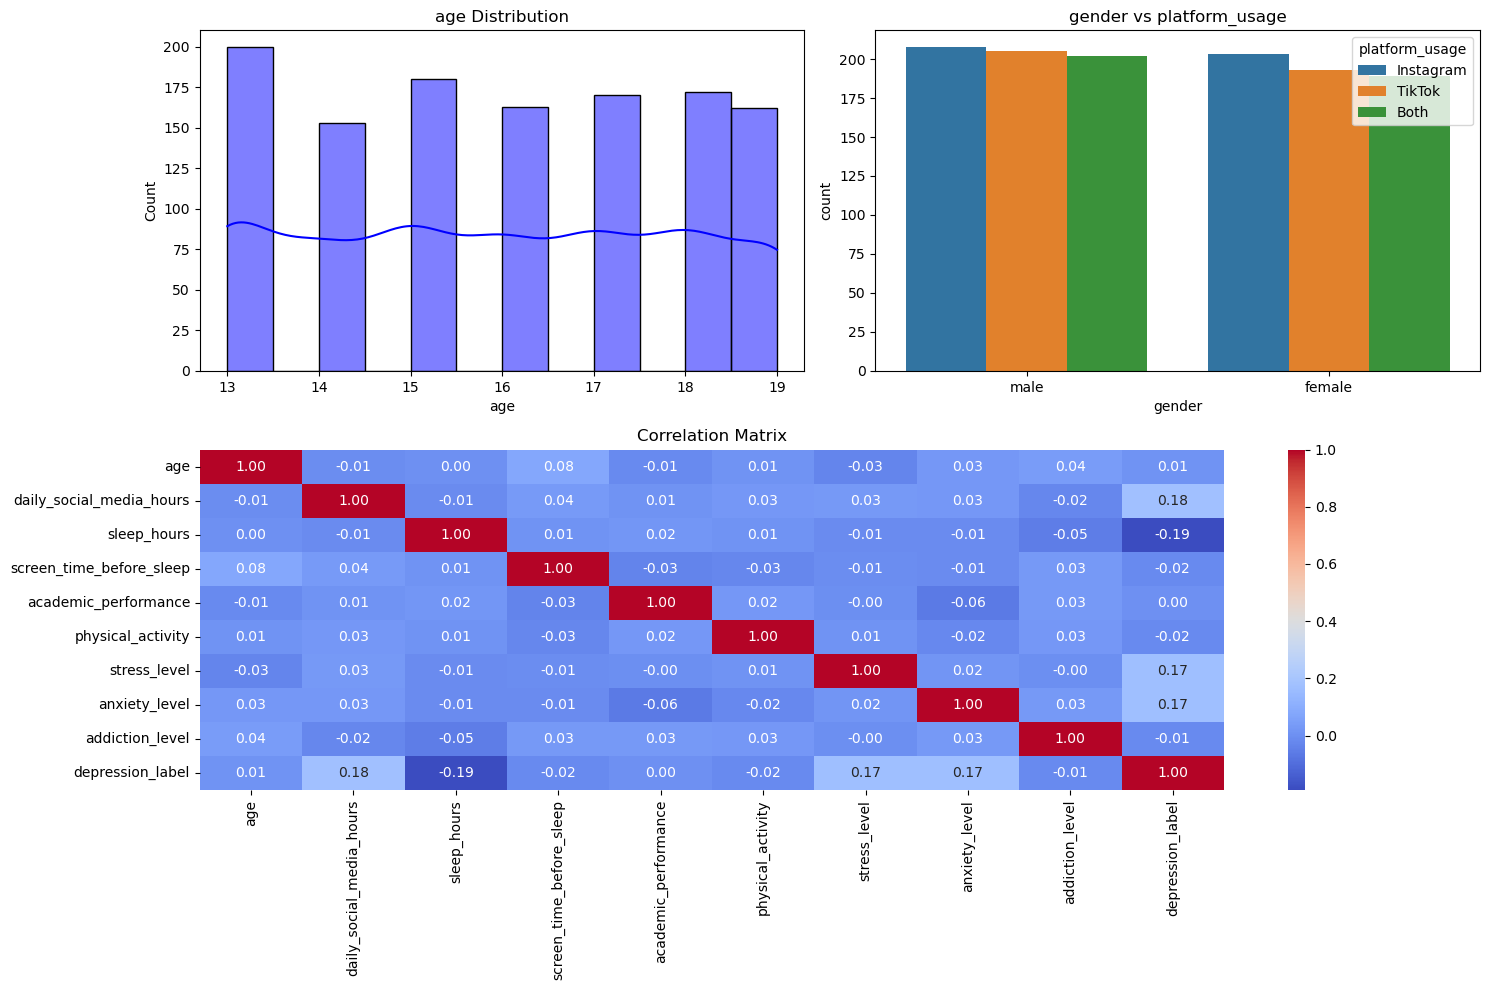

In [3]:
import seaborn as sns
import numpy as np

# Visualizing distributions
plt.figure(figsize=(15, 10))

# Screen time distribution -> Replaced with the first numerical column
numerical_cols = df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    first_num_col = numerical_cols[0]
    plt.subplot(2, 2, 1)
    sns.histplot(df[first_num_col], kde=True, color='blue')
    plt.title(f'{first_num_col} Distribution')

# Addiction Label vs Stress Level -> Dynamic check for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
if len(categorical_cols) >= 2:
    plt.subplot(2, 2, 2)
    sns.countplot(data=df, x=categorical_cols[0], hue=categorical_cols[1])
    plt.title(f'{categorical_cols[0]} vs {categorical_cols[1]}')
elif len(categorical_cols) == 1 and len(numerical_cols) > 0:
    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, x=categorical_cols[0], y=first_num_col)
    plt.title(f'{first_num_col} vs {categorical_cols[0]}')

# Correlation Matrix (Numerical only)
plt.subplot(2, 1, 2)
numerical_df = df.select_dtypes(include=[np.number])
if not numerical_df.empty:
    sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

# air quality 

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# In notebooks, you can use Path.cwd() to get the current working directory
# or use relative paths directly.
parent_dir = Path.cwd().parent
data_dir = parent_dir / "data" / "AirQualityUCI.xlsx"

# If the data folder is in the same directory as the notebook's parent:
# data_dir = Path("../data/data.csv")

# Use read_excel since the file is an Excel spreadsheet (.xlsx), not a CSV
df = pd.read_excel(data_dir)

# Display the first few rows of the DataFrame
print(df.head())


        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.725487  
2  11.90  53.975000 

Cleaned Data Shape: (9357, 15)

Missing Values per column:
 Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


,Date,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2004-09-21 04:30:05.193972480,2.152750,1099.707856,218.811816,10.082993,939.029205,246.881252,835.370973,113.075515,1456.143486,1022.780725,18.316054,49.232360,1.025530
min,2004-03-10 00:00:00,0.100000,647.250000,7.000000,0.149048,383.250000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,2004-06-16 00:00:00,1.100000,936.750000,67.000000,4.436942,734.375000,98.000000,657.875000,78.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,2004-09-21 00:00:00,1.800000,1063.000000,150.000000,8.239851,909.000000,179.800000,805.500000,109.000000,1462.750000,963.250000,17.750000,49.550000,0.995395
75%,2004-12-28 00:00:00,2.900000,1231.250000,297.000000,13.988478,1116.250000,326.000000,969.250000,142.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701
max,2005-04-04 00:00:00,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,339.700000,2775.000000,2522.750000,44.600000,88.725000,2.231036
std,NaN,1.453252,217.084571,204.459921,7.449640,266.829000,212.971224,256.815106,48.359250,346.204540,398.480897,8.832888,17.316389,0.403813


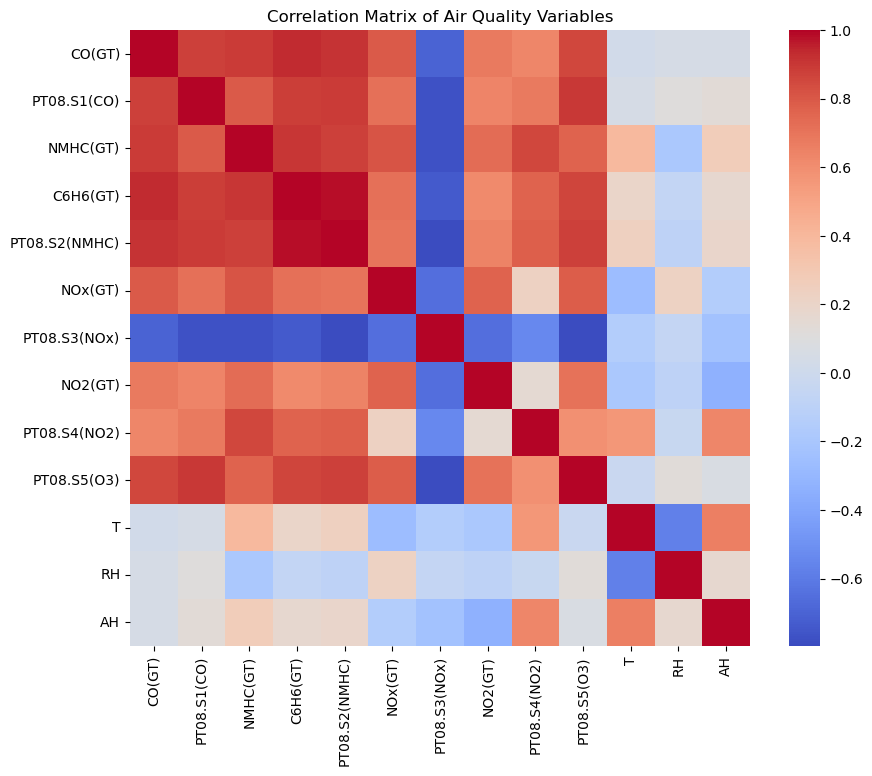

In [4]:
import seaborn as sns

# The Air Quality UCI dataset typically uses -200 to represent missing values.
# We will replace them with NaN so pandas can properly calculate statistics.
df_air = df.replace(-200, np.nan)

# Drop completely empty columns/rows if any were imported
df_air.dropna(how='all', axis=1, inplace=True)
df_air.dropna(how='all', axis=0, inplace=True)

print("Cleaned Data Shape:", df_air.shape)
print("\nMissing Values per column:\n", df_air.isnull().sum())

display(df_air.describe())

# Plotting the correlation matrix for sensor values
plt.figure(figsize=(10, 8))
# Select only numerical columns for the heatmap
num_air = df_air.select_dtypes(include=[np.number])
if not num_air.empty:
    sns.heatmap(num_air.corr(), annot=False, cmap='coolwarm')
    plt.title("Correlation Matrix of Air Quality Variables")
    plt.show()

### Air Quality UCI Dataset: Initial Analysis & MBML Project Ideas

#### 1. Dataset Summary
The Air Quality dataset contains hourly averaged responses from a metal oxide chemical multisensor device deployed in an Italian city. It includes:
*   **Ground Truths (`GT` columns)**: Reference hourly averages for CO, Non-Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx), and Nitrogen Dioxide (NO2) provided by a co-located reference analyzer.
*   **Sensor Readings (`PT08.S` columns)**: Raw sensor responses.
*   **Environmental Factors**: Temperature (`T`), Relative Humidity (`RH`), and Absolute Humidity (`AH`).

*(Crucial Note: The dataset conventionally uses `-200` to indicate missing values. In the cell above, we mapped these to `NaN` to see the true data distribution and missingness).*

---

#### 2. Project Ideas for Model-Based Machine Learning (MBML)

Since this course relies heavily on graphical models and probabilisitic programming (Pyro), here are a few excellent ways to tackle this dataset:

**Idea A: Probabilistic Sensor Calibration**
*   **The Problem:** Low-cost sensors drift over time and are heavily influenced by temperature and humidity. 
*   **The MBML Angle:** Build a Bayesian Regression or a Gaussian Process model to predict the *true* concentration (e.g., `CO(GT)`) using the raw sensor readings (e.g., `PT08.S1(CO)`) and environmental variables (`T`, `RH`) as inputs. 
*   **Why it's good:** You can model the "sensor drift" as a latent variable that slowly changes over time, proving the value of modeling uncertainty over standard neural networks.

**Idea B: Bayesian Missing Data Imputation (Latent Variables)**
*   **The Problem:** As seen in the EDA, there are thousands of missing values. Many traditional ML projects just drop these rows or use a poor mean-imputer.
*   **The MBML Angle:** Build a Generative Graphical Model that jointly models the correlations between the different gases. When a sensor fails, the known values of the other sensors (and the time of day) are passed into your Pyro model to infer a posterior distribution for the missing value. 
*   **Why it's good:** Treating missing data as latent variables to be inferred via Stochastic Variational Inference (SVI) is a classic, powerful MBML use case.

**Idea C: Time-Series Air Quality Forecasting (Structural Time Series)**
*   **The Problem:** Air pollution exhibits extremely strong daily (traffic hours) and weekly (weekends) seasonalities.
*   **The MBML Angle:** Construct a Bayesian structural time-series model (similar to what Prophet does under the hood) with latent states for `trend`, `daily_seasonality`, and `noise`. Predict the pollution levels for the next 24 hours.
*   **Why it's good:** It generates a full posterior predictive distribution (uncertainty bands) rather than just a point estimate, allowing you to say "We are 95% confident $NO_2$ will not exceed safe limits tomorrow."

Training Baseline Bayesian Regression over 7344 observations...
Step 0 : ELBO Loss = 14182.36
Step 300 : ELBO Loss = 5001.15
Step 600 : ELBO Loss = 5002.41
Step 900 : ELBO Loss = 4998.05
Step 1200 : ELBO Loss = 4995.96
Training Complete!

Learned Parameters (Posterior Medians):
Weight for Raw Sensor: 0.8798
Weight for Temperature: 0.0070
Bias: -0.0155


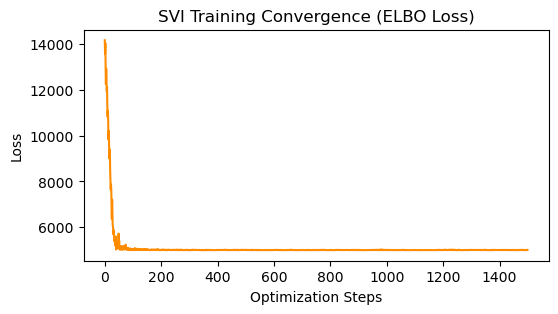

In [5]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import Adam

# 1. Prepare Data for a Simple Baseline Model
# We will predict True Level of Carbon Monoxide: 'CO(GT)' 
# using the cheap raw sensor 'PT08.S1(CO)' and Temperature 'T'
# For this simple baseline, we just drop the NaNs.
clean_df = df_air[['CO(GT)', 'PT08.S1(CO)', 'T']].dropna()

# Convert pandas to PyTorch tensors and Standardize (Z-score) 
# Standardizing is crucial so our Normal(0,1) priors are on the correct scale.
target_co = torch.tensor(clean_df['CO(GT)'].values, dtype=torch.float32)
target_co = (target_co - target_co.mean()) / target_co.std()

sensor_co = torch.tensor(clean_df['PT08.S1(CO)'].values, dtype=torch.float32)
sensor_co = (sensor_co - sensor_co.mean()) / sensor_co.std()

temp = torch.tensor(clean_df['T'].values, dtype=torch.float32)
temp = (temp - temp.mean()) / temp.std()

# 2. Define the Generative Pyro Model (Bayesian Linear Regression)
def simple_air_model(sensor, temp, obs=None):
    # Global Priors for the weights and bias
    w_sensor = pyro.sample("weight_sensor", dist.Normal(0.0, 1.0))
    w_temp = pyro.sample("weight_temp", dist.Normal(0.0, 1.0))
    bias = pyro.sample("bias", dist.Normal(0.0, 1.0))
    
    # Prior for the observation noise (must be positive)
    sigma = pyro.sample("sigma", dist.Uniform(0.0, 5.0))
    
    # Expected value (Deterministic deterministic mapping)
    mean = bias + w_sensor * sensor + w_temp * temp
    
    # Likelihood using pyro.plate for conditional independence
    with pyro.plate("data", len(sensor)):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=obs)

# 3. Setup Stochastic Variational Inference (SVI)
pyro.clear_param_store()

# AutoDiagonalNormal will automatically construct a guide (variational distribution) 
# assuming our posteriors are independent Normal distributions.
guide = AutoDiagonalNormal(simple_air_model)
optimizer = Adam({"lr": 0.05})
svi = SVI(simple_air_model, guide, optimizer, loss=Trace_ELBO())

# 4. Train the Model
n_steps = 1500
print(f"Training Baseline Bayesian Regression over {len(clean_df)} observations...")
losses = []
for step in range(n_steps):
    loss = svi.step(sensor_co, temp, target_co)
    losses.append(loss)
    if step % 300 == 0:
         print(f"Step {step} : ELBO Loss = {loss:.2f}")

print("Training Complete!")

# 5. Extract and print Learned Parameters
# We pull the expected median values from the approximated posterior distributions.
quantiles = guide.quantiles([0.5])
print("\nLearned Parameters (Posterior Medians):")
print(f"Weight for Raw Sensor: {quantiles['weight_sensor'][0].item():.4f}")
print(f"Weight for Temperature: {quantiles['weight_temp'][0].item():.4f}")
print(f"Bias: {quantiles['bias'][0].item():.4f}")

# Plot the training loss trajectory
plt.figure(figsize=(6, 3))
plt.plot(losses, color='darkorange')
plt.title("SVI Training Convergence (ELBO Loss)")
plt.xlabel("Optimization Steps")
plt.ylabel("Loss")
plt.show()

--- Baseline Model Performance (Standardized Units) ---
Mean Absolute Error (MAE): 0.3415
R-squared (R^2): 0.7723
-------------------------------------------------------


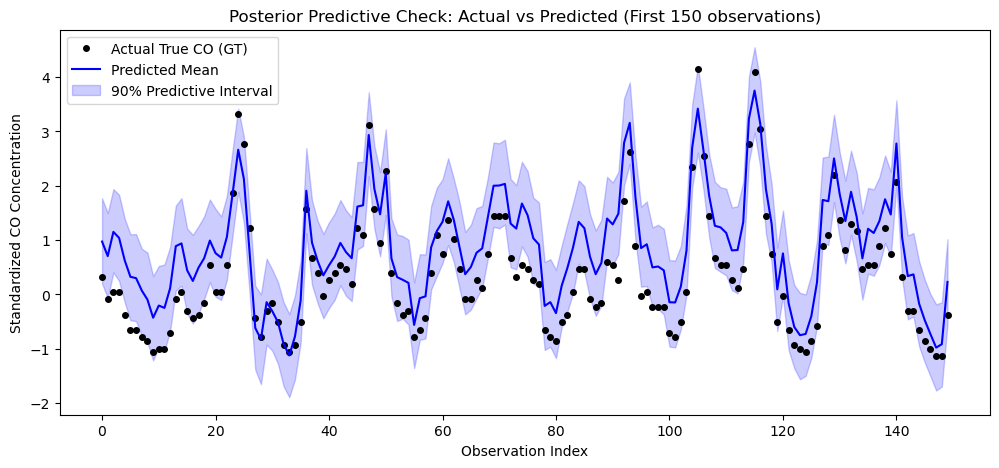

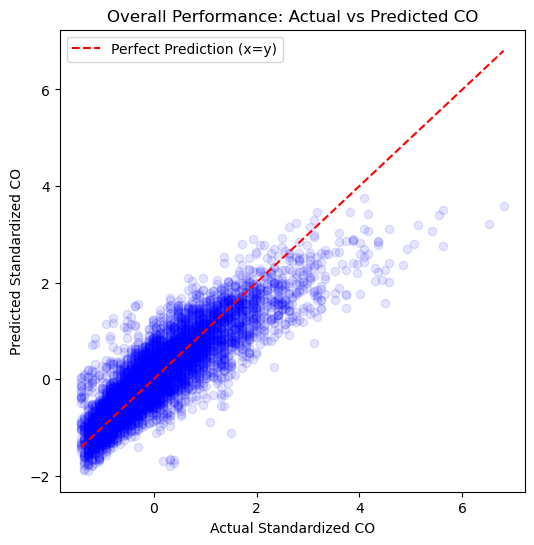

In [6]:
from pyro.infer import Predictive
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Generate Posterior Predictive Samples
# We sample 1,000 times from our trained model to get a distribution of predictions
predictive = Predictive(simple_air_model, guide=guide, num_samples=1000)
# Pass our input tensors to the predictive model
samples = predictive(sensor_co, temp)

# 2. Extract predictions
# 'obs' is the sampling site of our target variable defined in the pyro.sample("obs", ...) statement
pred_obs = samples['obs'] # Shape: (1000 samples, N observations)

# Calculate mean prediction and 90% Confidence Interval (5th and 95th percentiles)
pred_mean = pred_obs.mean(dim=0).detach().numpy()
pred_5 = torch.quantile(pred_obs, 0.05, dim=0).detach().numpy()
pred_95 = torch.quantile(pred_obs, 0.95, dim=0).detach().numpy()

actual = target_co.numpy()

# 3. Calculate classic Error Metrics (on the mean of the distribution)
mae = mean_absolute_error(actual, pred_mean)
r2 = r2_score(actual, pred_mean)

print(f"--- Baseline Model Performance (Standardized Units) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R^2): {r2:.4f}")
print("-------------------------------------------------------")

# 4. Plot Actual vs Predicted Time Series (Zoomed in on 150 points for visibility)
plt.figure(figsize=(12, 5))
n_plot = min(150, len(actual)) # Only plot a subset so we can see the variance

plt.plot(actual[:n_plot], label="Actual True CO (GT)", color='black', marker='o', markersize=4, linestyle='')
plt.plot(pred_mean[:n_plot], label="Predicted Mean", color='blue')
# This is the beauty of MBML: Modeling Uncertainty!
plt.fill_between(range(n_plot), pred_5[:n_plot], pred_95[:n_plot], color='blue', alpha=0.2, label='90% Predictive Interval')

plt.title("Posterior Predictive Check: Actual vs Predicted (First 150 observations)")
plt.xlabel("Observation Index")
plt.ylabel("Standardized CO Concentration")
plt.legend()
plt.show()

# 5. Global Scatter Plot (Actual vs Predicted over entire dataset)
plt.figure(figsize=(6, 6))
plt.scatter(actual, pred_mean, alpha=0.1, color='blue')
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', label='Perfect Prediction (x=y)')
plt.title("Overall Performance: Actual vs Predicted CO")
plt.xlabel("Actual Standardized CO")
plt.ylabel("Predicted Standardized CO")
plt.legend()
plt.show()

### Evaluating the Baseline Model (Posterior Predictive Check)

In Bayesian Machine Learning, we don't just calculate a point prediction; we generate a full **posterior predictive distribution**. We can sample from our trained model to see not only what it predicts the mean air quality to be, but also its **uncertainty** (the 90% confidence intervals) around each prediction. 

Let's sample 1,000 predictions for every observation and plot them against the actual Ground Truth values.

## Full MBML Project Plan: Bayesian Air Quality Sensor Calibration & Imputation

This project will model how cheap environmental sensors drift over time and how we can use probabilistic programming to inherently handle their frequent failures (missing data) without discarding valuable data.

### Phase 1: The Foundation (DAG & EDA)
*   **Data Prep**: Parse dates into temporal cyclical features (hour of day, day of week). Map ` -200` to `NaN` and standardize all numeric variables. 
*   **Draw the Box Setup / DAG**: Design a Directed Acyclic Graph. 
    *   *Nodes expected:* True CO concentration, Raw Sensor CO, Temperature, Humidity, Time of Day. 
    *   *Arrows:* True CO $\rightarrow$ Raw Sensor. Temp & Humidity $\rightarrow$ Raw Sensor.

### Phase 2: The Fully Observed Baseline Model (Implemented Above)
*   **Action**: Build a simple Bayesian Linear Regression (or robust regression using Student-T distribution to handle outliers) using only data rows that have no NaNs.
*   **Goal**: Establish base relationships. Verify that PyTorch/Pyro standardizes correctly, converges via Variational Inference (SVI), and yields logical weights (e.g., verifying that the raw sensor correlates positively with the true CO, and learning the effect temperature has on sensor accuracy).

### Phase 3: Embracing the MBML Philosophy (Latent NaN Imputation)
*   **The Flaw of Baseline**: Tossing rows with missing values (like we did in Phase 2) ruins the dataset and violates MBML principles.
*   **The Upgrade**: Treat missing sensor readings or missing ground-truths as **Latent Variables**.
*   **Implementation in Pyro**: Instead of `dropna()`, iterate through the dataset. If `CO(GT)` is missing, do *not* pass the `obs=` kwarg to `pyro.sample` for that row. Pyro will automatically infer the posterior distribution of that missing value given the other observed sensors on that day!

### Phase 4: Adding Hierarchical/Dynamic Components
*   **Sensor Degradation**: The cheap chemical sensors degrade over the year. Add a latent variable `drift` that follows a Gaussian Random Walk across weeks/months.
*   *Math:* $y_{obs} \sim \text{Normal}(weight \cdot true\_gas + \text{drift}_t, \sigma)$

### Phase 5: Evaluation & Model Criticism
*   **Posterior Predictive Checks (PPC)**: Simulate new data from the trained models and overlay it on the actual sensor data to see if the predictive distributions cover the true variation.
*   **Evaluating Imputation**: Hide 10% of known values, ask the model to infer them, and compute the RMSE/Coverage of our posterior distributions against the true hidden values.
*   **Comparison**: Compare the ELBO loss and predictive accuracy of the simple baseline model against the advanced Hierarchical Imputation model.